In [37]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

iris = load_iris()
# print(iris.data[:5]) 
# print(iris.target[:5])
# print(iris.feature_names)
# print(iris.target_names)
# print(iris.data.shape)

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [38]:
df = df[['petal length (cm)','petal width (cm)']]
df.head()

,petal length (cm),petal width (cm)
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2


C:\Users\maheshwaran.mahesh\AppData\Local\Temp\ipykernel_27660\513313978.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


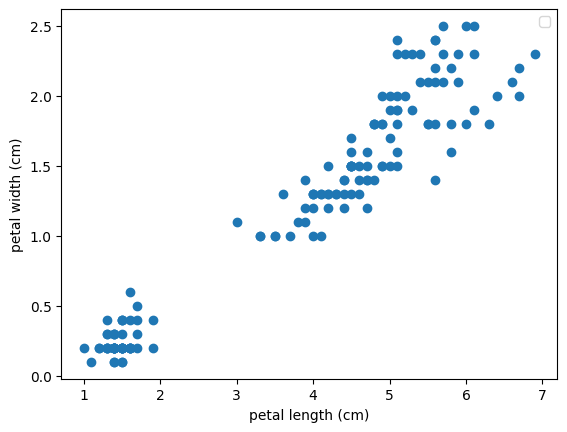

In [39]:
plt.scatter(df['petal length (cm)'], df['petal width (cm)'])
plt.xlabel("petal length (cm)")
plt.ylabel("petal width (cm)")
plt.legend()
plt.show()

In [44]:
scalar = StandardScaler()
df_scaled = scalar.fit_transform(df)
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)

model = KMeans(n_clusters=2)
model.fit(df_scaled)
clusters = model.predict(df_scaled)
df_scaled['cluster'] = clusters

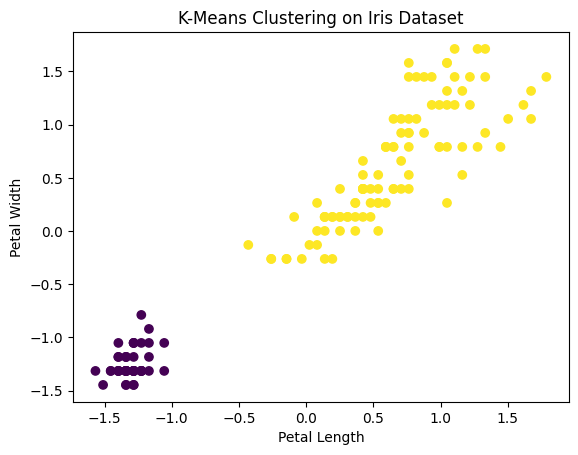

[[-1.30498732 -1.25489349]
 [ 0.65249366  0.62744675]]


In [45]:
plt.scatter(df_scaled['petal length (cm)'], df_scaled['petal width (cm)'], c=df_scaled['cluster'])

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("K-Means Clustering on Iris Dataset")

plt.show()

print(model.cluster_centers_)

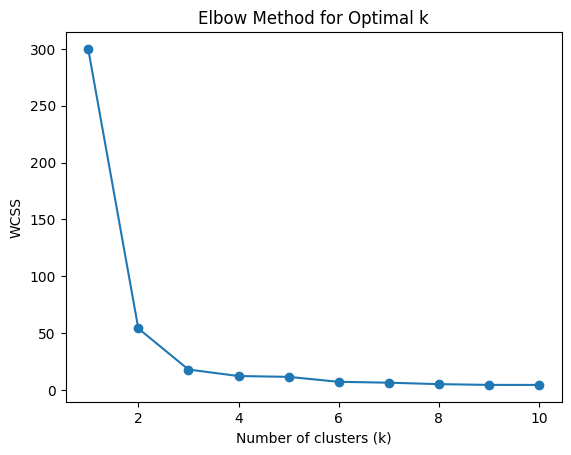

In [46]:
X = df_scaled[['petal length (cm)', 'petal width (cm)']]
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal k")
plt.show()